## Similarity-based RUL Prediction

In [317]:
import pandas as pd
import numpy as np

#to plot the data
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

import time
import os


from sklearn.preprocessing import MinMaxScaler #to normalize data
from sklearn.preprocessing import minmax_scale
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.utils import class_weight

In [318]:
y_true= pd.read_csv('RUL_FD001.txt',sep="\s+",names=["RUL"])
df_train = pd.read_csv("train_cleaned_data.csv")
df_test = pd.read_csv("test_data.csv")

In [319]:
df_train.shape, df_test.shape, y_true.shape

((20631, 20), (13096, 26), (100, 1))

In [320]:
feats = df_train.columns.drop(['UnitNumber', 'Cycle', 'RUL'])

In [321]:
sc = MinMaxScaler(feature_range=(0,1))

df_train[feats] = sc.fit_transform(df_train[feats])
df_test[feats] = sc.transform(df_test[feats])

In [322]:
df_train.head()

,UnitNumber,Cycle,OpSet1,OpSet2,SensorMeasure2,SensorMeasure3,SensorMeasure4,SensorMeasure6,SensorMeasure7,SensorMeasure8,SensorMeasure9,SensorMeasure11,SensorMeasure12,SensorMeasure13,SensorMeasure14,SensorMeasure15,SensorMeasure17,SensorMeasure20,SensorMeasure21,RUL
0,1,1,0.459770,0.166667,0.183735,0.406802,0.309757,1.0,0.726248,0.242424,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662,191
1,1,2,0.609195,0.250000,0.283133,0.453019,0.352633,1.0,0.628019,0.212121,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014,190
2,1,3,0.252874,0.750000,0.343373,0.369523,0.370527,1.0,0.710145,0.272727,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375,189
3,1,4,0.540230,0.500000,0.343373,0.256159,0.331195,1.0,0.740741,0.318182,0.124518,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386,188
4,1,5,0.390805,0.333333,0.349398,0.257467,0.404625,1.0,0.668277,0.242424,0.149960,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502,187


In [323]:
df_test.head()

,UnitNumber,Cycle,OpSet1,OpSet2,OpSet3,SensorMeasure1,SensorMeasure2,SensorMeasure3,SensorMeasure4,SensorMeasure5,...,SensorMeasure12,SensorMeasure13,SensorMeasure14,SensorMeasure15,SensorMeasure16,SensorMeasure17,SensorMeasure18,SensorMeasure19,SensorMeasure20,SensorMeasure21
0,1,1,0.632184,0.750000,100.0,518.67,0.545181,0.310661,0.269413,14.62,...,0.646055,0.220588,0.132160,0.308965,0.03,0.333333,2388,100.0,0.558140,0.661834
1,1,2,0.344828,0.250000,100.0,518.67,0.150602,0.379551,0.222316,14.62,...,0.739872,0.264706,0.204768,0.213159,0.03,0.416667,2388,100.0,0.682171,0.686827
2,1,3,0.517241,0.583333,100.0,518.67,0.376506,0.346632,0.322248,14.62,...,0.699360,0.220588,0.155640,0.458638,0.03,0.416667,2388,100.0,0.728682,0.721348
3,1,4,0.741379,0.500000,100.0,518.67,0.370482,0.285154,0.408001,14.62,...,0.573561,0.250000,0.170090,0.257022,0.03,0.250000,2388,100.0,0.666667,0.662110
4,1,5,0.580460,0.500000,100.0,518.67,0.391566,0.352082,0.332039,14.62,...,0.737740,0.220588,0.152751,0.300885,0.03,0.166667,2388,100.0,0.658915,0.716377


### Selecting features using Trendability

\begin{equation*}
Trendability \ (x) = | \frac{1}{M} \sum_{j=1}^{M} \ corr(x_j, t_j) |
\end{equation*}

Finding the average correlation of features with time.

Where j is unit.

In [324]:
def trendability(col):
    
    trend_vals = []
    
    for i in df_train.UnitNumber.unique():
        dff = df_train[df_train.UnitNumber == i]
        trend_vals.append(dff[['Cycle', col]].corr().iloc[0][1])
        
    return np.abs(np.mean(trend_vals))

In [325]:
rows = []
for col in feats:
    rows.append({'feature': col,'trendability_val': trendability(col)})
trend_df = pd.DataFrame(rows)

C:\Users\umesh\AppData\Local\Temp\ipykernel_24096\498095111.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  trend_vals.append(dff[['Cycle', col]].corr().iloc[0][1])
C:\Users\umesh\AppData\Local\Temp\ipykernel_24096\498095111.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  trend_vals.append(dff[['Cycle', col]].corr().iloc[0][1])
C:\Users\umesh\AppData\Local\Temp\ipykernel_24096\498095111.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser

In [326]:
trend_df = trend_df.sort_values(by = 'trendability_val', ascending = False)
trend_df.head()

,feature,trendability_val
9,SensorMeasure11,0.810601
10,SensorMeasure12,0.789662
4,SensorMeasure4,0.781614
6,SensorMeasure7,0.761514
13,SensorMeasure15,0.724844


In [327]:
fig, ax = plt.subplots(figsize = (7,10))

sns.barplot(y = trend_df.feature, x = trend_df.trendability_val)

<Axes: xlabel='trendability_val', ylabel='feature'>

Selecting features having trendability higher than 0.2

In [328]:
feats = trend_df.feature[trend_df.trendability_val > 0.2]
feats

9     SensorMeasure11
10    SensorMeasure12
4      SensorMeasure4
6      SensorMeasure7
13    SensorMeasure15
16    SensorMeasure21
15    SensorMeasure20
11    SensorMeasure13
7      SensorMeasure8
2      SensorMeasure2
14    SensorMeasure17
3      SensorMeasure3
8      SensorMeasure9
12    SensorMeasure14
Name: feature, dtype: object

In [329]:
len(feats)

14

### Creating a Linear Degradation model to fuse these features

Let's assume health condition of a unit is degrading linearly which can be achieved by rescaling RUL having 1-0 scale

In [330]:
df_train['HI'] = df_train.groupby('UnitNumber').RUL.transform(lambda x: minmax_scale(x))

Visualizing health indicators of 1-30 units

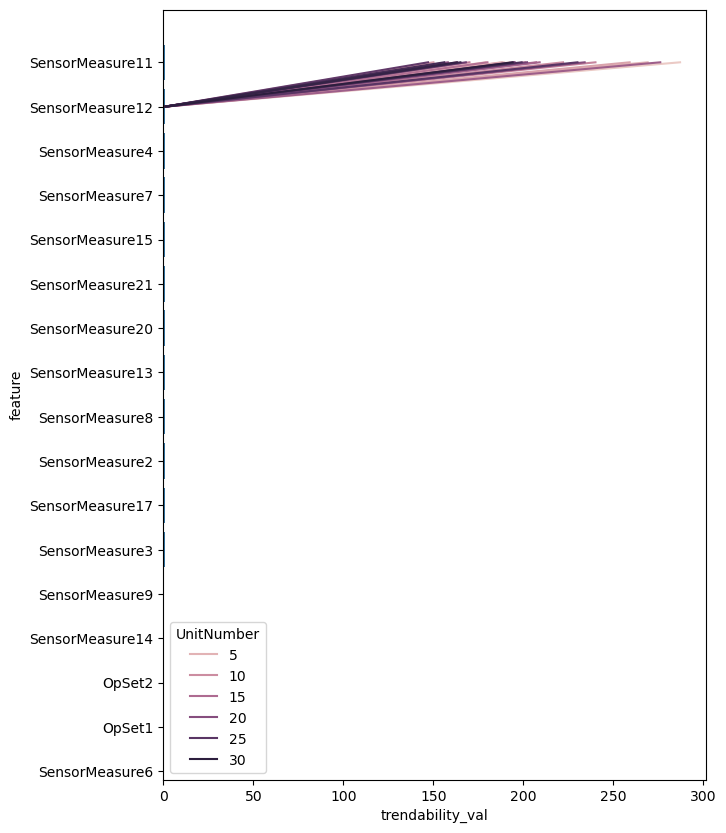

In [331]:
sns.lineplot(data= df_train[df_train.UnitNumber < 31], x = 'Cycle', y = 'HI', hue= 'UnitNumber')
plt.show()

### Fiting a linear regression model of health condition with most trended features.

In [332]:
model = LinearRegression()

In [333]:
X = df_train[feats]
y = df_train.HI

X.shape, y.shape

((20631, 14), (20631,))

In [334]:
model.fit(X,y)

model.score(X,y)

0.6520059883900058

In [335]:
model.coef_

array([-0.26884914,  0.24180177, -0.20064758,  0.18905397, -0.12967532,
        0.13174699,  0.13877304, -0.0241087 ,  0.01229191, -0.08003577,
       -0.10509745, -0.09005357, -0.4145927 , -0.27325302])

In [336]:
len(model.coef_)

14

In [337]:
model.intercept_

np.float64(0.6333546734289237)

### Constructing a new health indicator by multiplying model coefficient with features

In [338]:
df_train['HI_final'] = df_train[feats].dot(model.coef_)
df_train.HI_final.head()

0    0.087893
1    0.077465
2    0.122410
3    0.200864
4    0.071672
Name: HI_final, dtype: float64

Let's visualize final Health Indicators for 1-30 units

In [339]:
sns.lineplot(data= df_train[df_train.UnitNumber < 31], x = 'Cycle', y = 'HI_final', hue= 'UnitNumber')
plt.ylabel('Health Indicator')

Text(0, 0.5, 'Health Indicator')

Smoothing the final health indicator to reduce noise.

In [340]:
window = 5

In [341]:
df_train_HI = df_train.groupby('UnitNumber')['HI_final'].rolling(window = window).mean()
df_train_HI = df_train_HI.reset_index()
df_train_HI.dropna(inplace = True)
df_train_HI.drop(['level_1'], axis = 1, inplace = True)
df_train_HI['cycle'] = df_train_HI.groupby('UnitNumber').cumcount()+1
df_train_HI.head()

,UnitNumber,HI_final,cycle
4,1,0.112061,1
5,1,0.125402,2
6,1,0.133693,3
7,1,0.139125,4
8,1,0.128823,5


Visualizing health indicators of all units and their failures

In [342]:
for i in range(1,101):
    sns.lineplot(data= df_train_HI[df_train_HI.UnitNumber == i], x = 'cycle', y = 'HI_final', color = 'green', lw = 0.2)

sns.scatterplot(data = df_train[df_train.HI == 0], x = 'Cycle', y = 'HI_final', label = 'Failure', 
                marker = 'X', color = 'black')
plt.ylabel('Health Indicator')

Text(0, 0.5, 'Health Indicator')

### Fitting a second order polynomial function on these health indicators


$$ y = \theta_0 + \theta_1  x + \theta_2  x^2 $$

where y is a health indicator and x is a cycle

In [343]:
rows = []

for i in range(1, 101):
    subset = df_train_HI[df_train_HI.UnitNumber == i]
    theta_2, theta_1, theta_0 = np.polyfit(subset.cycle, subset.HI_final, 2)

    rows.append([i, theta_2, theta_1, theta_0])

params_df = pd.DataFrame(rows, columns=['UnitNumber', 'theta_2', 'theta_1', 'theta_0'])

In [344]:
params_df.head()

,UnitNumber,theta_2,theta_1,theta_0
0,1,-0.000026,0.001935,0.081240
1,2,-0.000018,0.002209,0.156074
2,3,-0.000054,0.004785,0.046752
3,4,-0.000049,0.005086,-0.053809
4,5,-0.000022,0.002535,0.096549


Visualizing for unit 1

In [345]:
HI = df_train_HI.HI_final[df_train_HI.UnitNumber == 1]
cycle = df_train_HI.cycle[df_train_HI.UnitNumber == 1]

theta_0 = params_df.theta_0[params_df.UnitNumber == 1].values
theta_1 = params_df.theta_1[params_df.UnitNumber == 1].values
theta_2 = params_df.theta_2[params_df.UnitNumber == 1].values

HI_fit = theta_0 + theta_1*cycle + theta_2*cycle*cycle

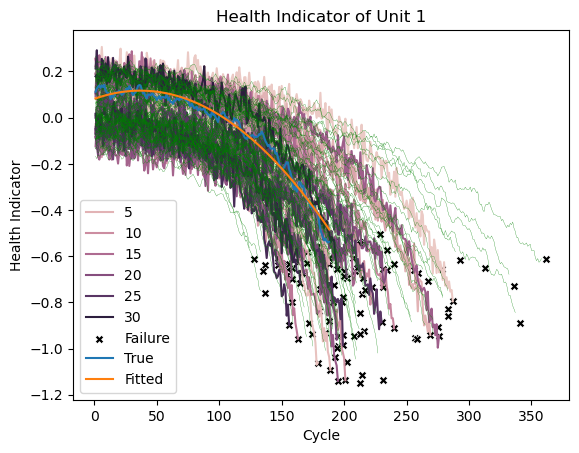

In [346]:
plt.plot(cycle,HI, label = 'True')
plt.plot(cycle,HI_fit, label = 'Fitted')
plt.ylabel('Health Indicator')
plt.xlabel('Cycle')
plt.legend()
plt.title('Health Indicator of Unit 1');
plt.show()

Visualzing for all units

In [347]:
fig, ax = plt.subplots(nrows = 20, ncols = 5, figsize = (30,50))

ax = ax.ravel()

for i in range(0,100):
    
    theta_0 = params_df.theta_0[params_df.UnitNumber == i+1].values
    theta_1 = params_df.theta_1[params_df.UnitNumber == i+1].values
    theta_2 = params_df.theta_2[params_df.UnitNumber == i+1].values
    
    cycle = df_train_HI.cycle[df_train_HI.UnitNumber == i+1]
    fit_HI = theta_0 + theta_1*cycle + theta_2*cycle*cycle
    
    sns.lineplot(data = df_train_HI[df_train_HI.UnitNumber == i+1], x = "cycle", y = "HI_final", ax = ax[i])
    sns.lineplot(y = fit_HI, x = cycle, ax = ax[i], color = "green")
    ax[i].set_title("Unit:" + str(i+1))
    ax[i].set_xlabel("")
    ax[i].set_ylabel("")

plt.tight_layout()

### Building a similartiy based RUL model

Steps:

1. Generate a health indicator by multipying weights to selected features in test data
2. Take a rolling mean of Health Indicator to reduce noise
3. Compare the fitted polynomial models with health indicators of test data and find 1-norm residuals using below equation

    $$ d(i,j) = ||y_j - \hat{y_{j,i}} ||_1 $$
    
4. Find similarity score using following formula

    $$ score(i,j) = exp(-d(i,j)^2) $$
   
5. Find top 50 most similar models
6. Find RUL by subtracting current cycle from total cycles of most similar units

#### Step 1

In [348]:
df_test['HI'] = df_test[feats].dot(model.coef_)
df_test.HI.head()

0    0.095656
1    0.128882
2    0.051068
3    0.087381
4    0.148141
Name: HI, dtype: float64

#### Step 2

In [349]:
df_test_HI = df_test.groupby('UnitNumber')['HI'].rolling(window = window).mean()
df_test_HI = df_test_HI.reset_index()
df_test_HI.dropna(inplace = True)
df_test_HI.drop(['level_1'], axis = 1, inplace = True)
df_test_HI['cycle'] = df_test_HI.groupby('UnitNumber').cumcount()+1
df_test_HI.head()

,UnitNumber,HI,cycle
4,1,0.102226,1
5,1,0.110121,2
6,1,0.103964,3
7,1,0.114302,4
8,1,0.115011,5


#### Step 3 and Step 4

In [350]:
l = df_train.groupby('UnitNumber')['Cycle'].max().to_dict()
p = params_df.set_index('UnitNumber').to_dict('index')



In [351]:
rows = []
for i in df_test_HI.UnitNumber.unique():
    
    d = df_test_HI[df_test_HI.UnitNumber == i]
    h = d.HI
    c = d.cycle

    for j in p:
        
        t0 = p[j]['theta_0']
        t1 = p[j]['theta_1']
        t2 = p[j]['theta_2']
        
        pred = t0 + t1*c + t2*c*c
        
        r = np.mean(np.abs(pred - h))
        s = np.exp(-r*r)
        tl = l[j]
        
        rows.append([i, j, r, s, tl])


In [352]:

df_test_fit = pd.DataFrame(rows, columns=[
    'UnitNumber', 'Model', 'Residual', 'similarity', 'total_life'
])

In [353]:
df_test_fit.head()

,UnitNumber,Model,Residual,similarity,total_life
0,1,1,0.018282,0.999666,192
1,1,2,0.072895,0.994700,287
2,1,3,0.031416,0.999014,179
3,1,4,0.104821,0.989073,189
4,1,5,0.024883,0.999381,269


#### Step 5 and 6

*Selecting 5 most similar units*

In [354]:
df_50 = df_test_fit.groupby('UnitNumber')['similarity'].nlargest(5)
df_50 = df_50.reset_index()
idx = df_50['level_1']
result_df_50 = df_test_fit.iloc[idx]
result_df_50.head()

,UnitNumber,Model,Residual,similarity,total_life
97,1,98,0.014982,0.999776,156
0,1,1,0.018282,0.999666,192
92,1,93,0.020012,0.999600,155
94,1,95,0.020760,0.999569,283
88,1,89,0.022995,0.999471,217


In [355]:
len(result_df_50)

500

Visualizing 5 most similar units to unit 5 of test data

In [356]:
d = result_df_50[result_df_50.UnitNumber == 3]
t = df_test_HI[df_test_HI.UnitNumber == 5]

In [357]:
for m in d.Model.unique():
    
    tr = df_train_HI[df_train_HI.UnitNumber == m]
    sns.lineplot(data=tr, x='cycle', y='HI_final',
                 color='green', lw=0.2)
    
    f = df_train[(df_train.UnitNumber == m) & (df_train.HI == 0)]
    sns.scatterplot(data=f, x='Cycle', y='HI_final',
                    marker='X', color='black')

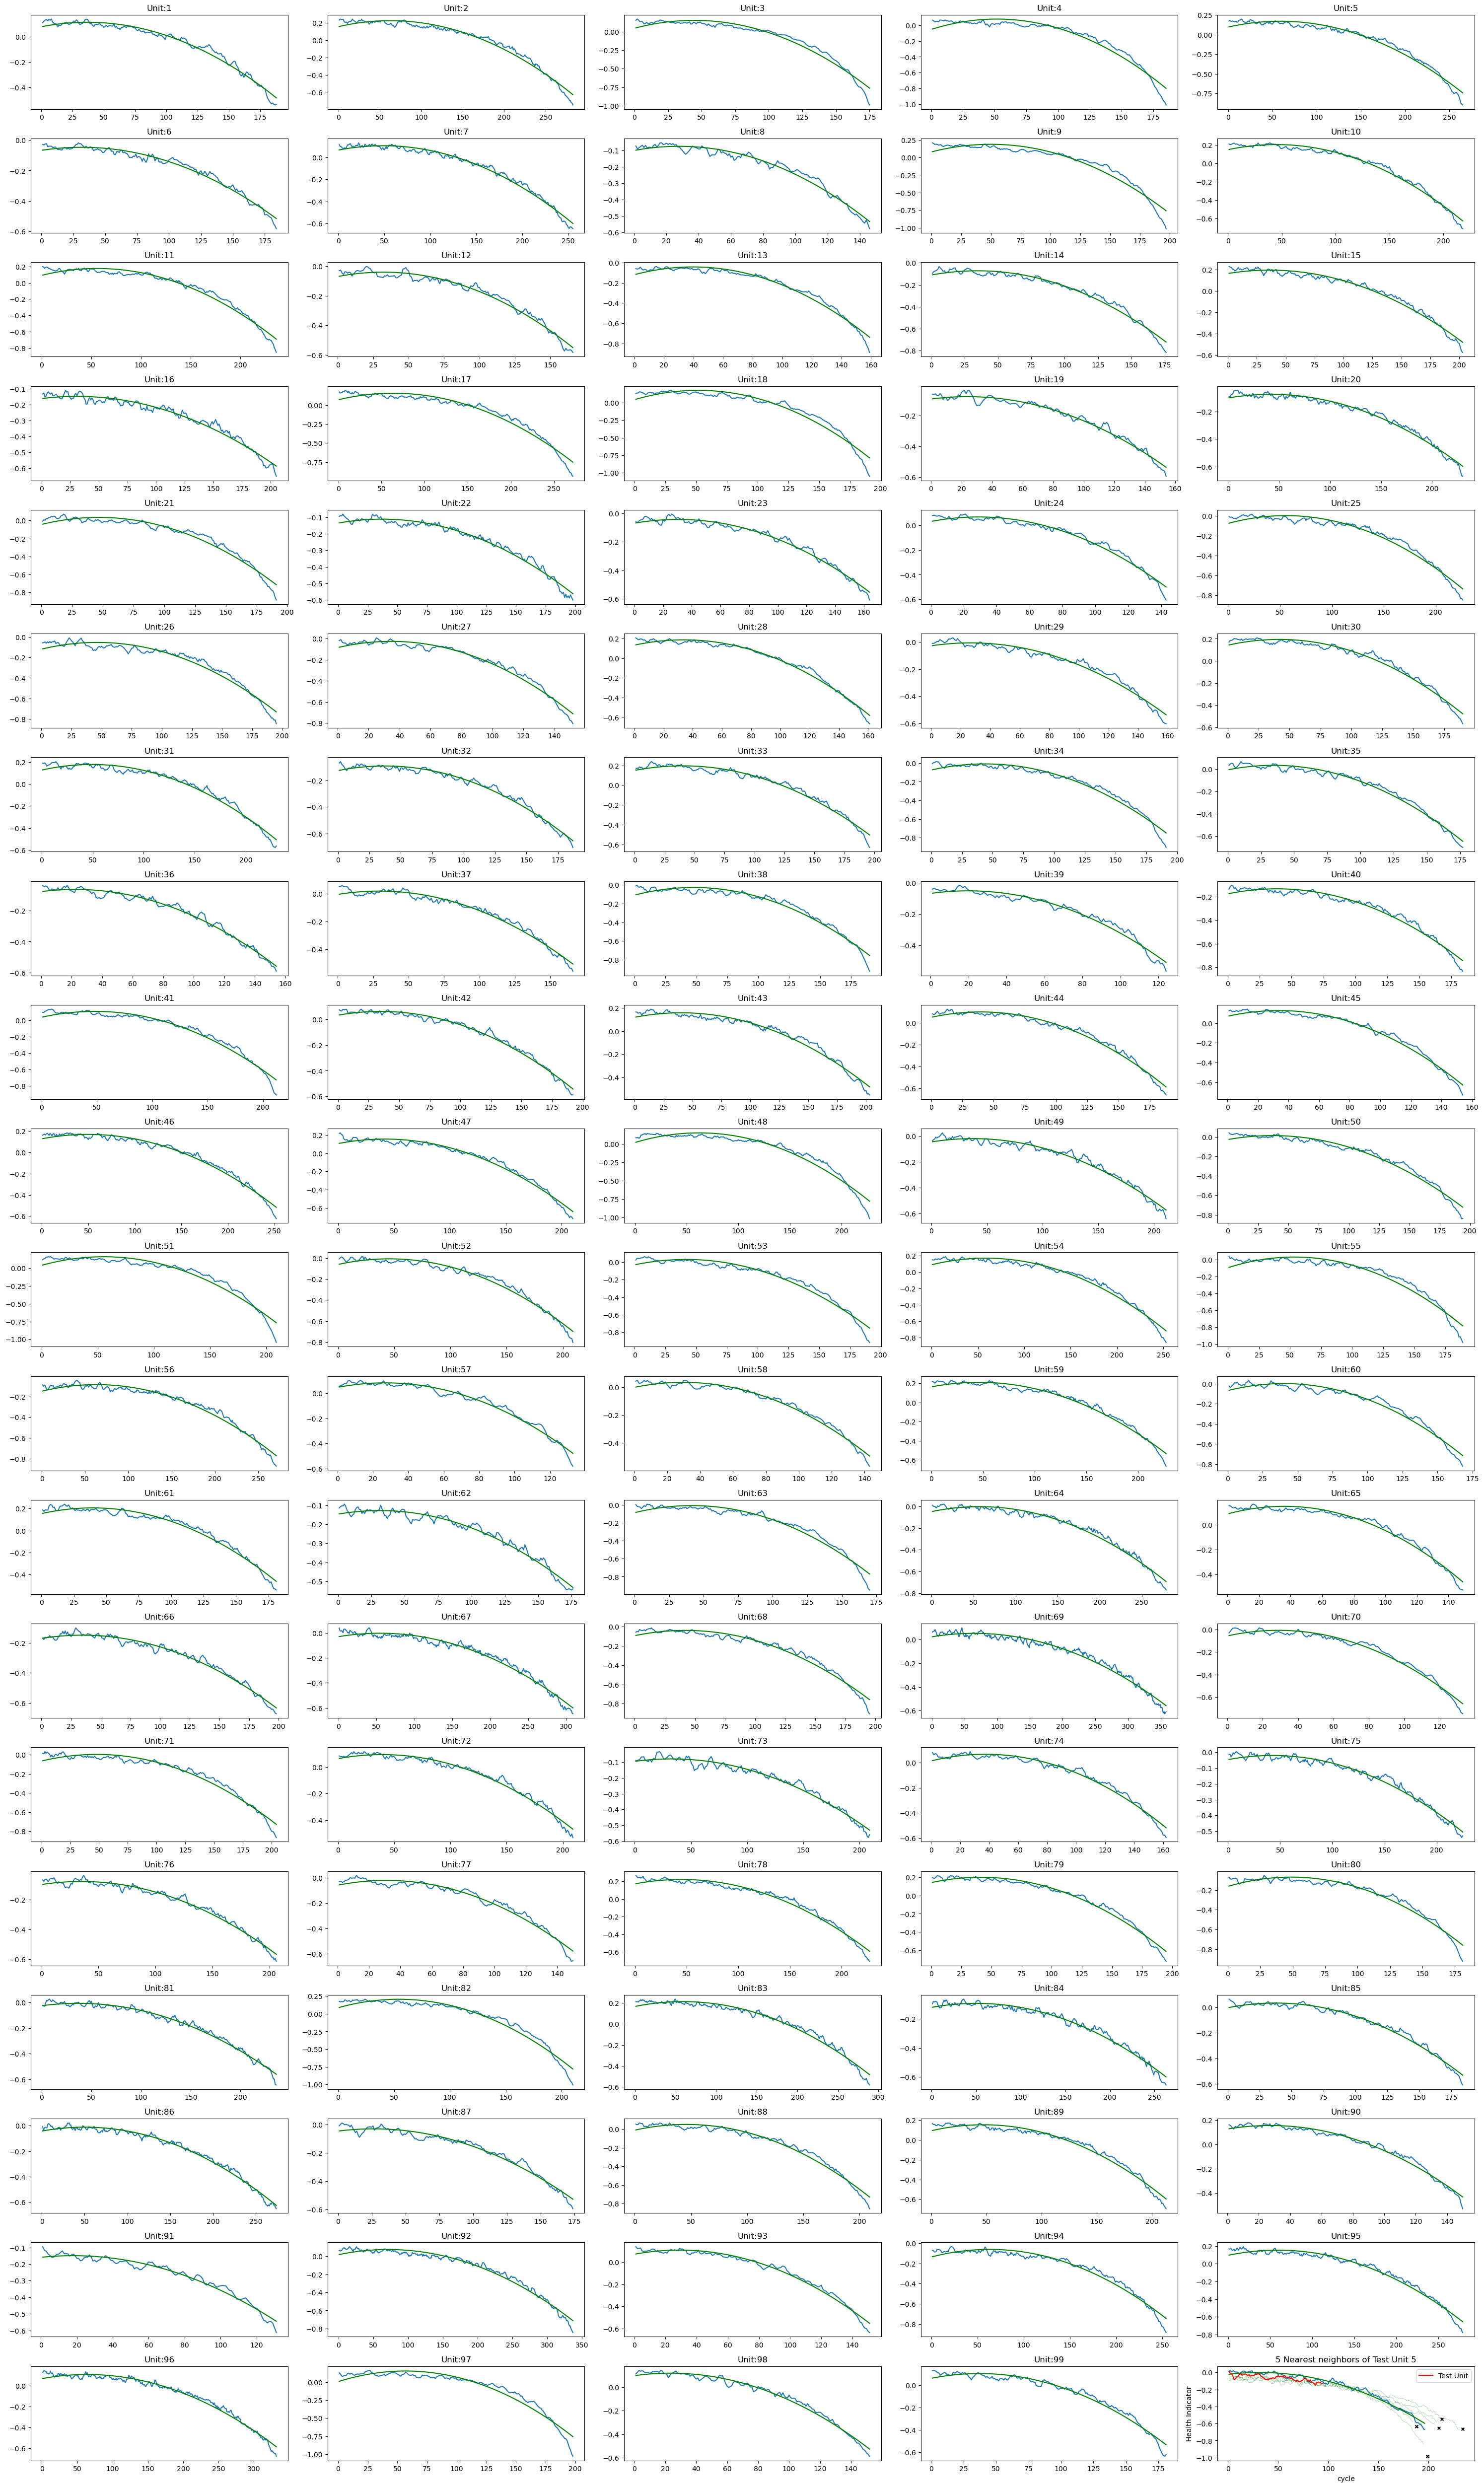

In [358]:
sns.lineplot(data=t, x='cycle', y='HI',
             color='red', label='Test Unit')

plt.ylabel('Health Indicator')
plt.title('5 Nearest neighbors of Test Unit 5')
plt.show()

#### Step 7

In [359]:
y_true_5 = y_true.copy()

y_true_5['Pred_RUL'] = (result_df_50.groupby('UnitNumber')['total_life'].mean() - df_test.groupby('UnitNumber')['Cycle'].max()).values
y_true_5.head()

,RUL,Pred_RUL
0,112,169.6
1,98,161.8
2,69,82.8
3,82,73.6
4,91,73.6


### Results

In [360]:
sns.regplot(x = y_true_5.Pred_RUL, y = y_true_5.RUL)
plt.xlabel('Predicted RUL')
plt.ylabel('True RUL')

Text(0, 0.5, 'True RUL')

In [361]:
fig, ax = plt.subplots(figsize = (15, 7))
sns.lineplot(x = y_true_5.UnitNumber, y = y_true_5.Pred_RUL, label = "Predicted RUL")
sns.lineplot(x = y_true_5.UnitNumber, y = y_true_5.RUL, label = "True RUL")
plt.xlabel("Unit Number")
plt.ylabel("Remaining Useful Life")
plt.legend(loc = 1)

AttributeError: 'DataFrame' object has no attribute 'UnitNumber'

### Errors

In [ ]:
mean_squared_error(y_true_5.RUL, y_true_5.Pred_RUL)

530.5268000000001

In [ ]:
mean_absolute_error(y_true_5.RUL, y_true_5.Pred_RUL)

16.81

In [ ]:
def mean_absolute_percentage_error(y_true, y_pred): 
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [ ]:
mean_absolute_percentage_error(y_true_5.RUL, y_true_5.Pred_RUL)

34.76065468809448